In [22]:
import os
import sys

# Set up project path
project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Force reload of modules to ensure fresh imports
import importlib
if 'src.utils.data_loader' in sys.modules:
    del sys.modules['src.utils.data_loader']
if 'src.utils' in sys.modules:
    del sys.modules['src.utils']
if 'src' in sys.modules:
    del sys.modules['src']

print(f"Project Root: {project_root}")

Project Root: /Users/gayathri/Documents/SJSU/255/HybridReco


## Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.data_loader import DataLoader
from src.algorithms.apriori_arm import AprioriARM

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Transaction Data

In [24]:
# Load data files
users_path = os.path.join(project_root, 'data/users.csv')
products_path = os.path.join(project_root, 'data/products.csv')
transactions_path = os.path.join(project_root, 'data/transactions.csv')

print(f"Loading data files...")
users_df = DataLoader.load_users(users_path)
products_df = DataLoader.load_products(products_path)
transactions_df = DataLoader.load_transactions(transactions_path)

print(f"✓ Users: {len(users_df)}")
print(f"✓ Products: {len(products_df)}")
print(f"✓ Transactions: {len(transactions_df)}")

# Create baskets for Apriori
baskets_df = DataLoader.create_transaction_baskets(transactions_df)
print(f"✓ Created {len(baskets_df)} baskets")
print(f"\nBasket information:")
print(f"  Sample basket:")
print(baskets_df.head(2))

Loading data files...
✓ Users: 6
✓ Products: 8
✓ Transactions: 29
✓ Created 12 baskets

Basket information:
  Sample basket:
  basket_id         items
0        O1  [P1, P2, P3]
1       O10      [P3, P8]


## 2. Initialize Apriori Model

In [25]:
# Train Apriori ARM model
arm_model = AprioriARM(min_support=0.01, min_confidence=0.3, min_lift=1.0)
arm_model.fit(baskets_df)

print("✓ Apriori ARM Model trained")
summary = arm_model.get_rules_summary()
print(f"\nModel Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

✓ Apriori ARM Model trained

Model Summary:
  n_rules: 37
  n_frequent_itemsets: 23
  avg_support: 0.14639639639639634
  avg_confidence: 0.6036036036036034
  avg_lift: 2.031531531531532
  max_lift: 4.0
  min_lift: 1.0


/Users/gayathri/Documents/SJSU/255/HybridReco/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


## 3. Train Apriori Model

In [26]:
# Model already trained in previous cell, just display summary
if arm_model is not None:
    print("✓ Apriori ARM Model is trained")
    summary = arm_model.get_rules_summary()
    print(f"\nRules Summary:")
    for key, value in summary.items():
        print(f"  {key}: {value}")

✓ Apriori ARM Model is trained

Rules Summary:
  n_rules: 37
  n_frequent_itemsets: 23
  avg_support: 0.14639639639639634
  avg_confidence: 0.6036036036036034
  avg_lift: 2.031531531531532
  max_lift: 4.0
  min_lift: 1.0


## 4. Examine Frequent Itemsets

In [27]:
# Get recommendations for a sample user
sample_user_id = 'U1'
sample_user_items = transactions_df[transactions_df['user_id'] == sample_user_id]['product_id'].unique().tolist()

print(f"User {sample_user_id} purchased: {sample_user_items}")

# Get recommendations
recs = arm_model.get_recommendations(sample_user_items, n_items=5)
print(f"\nApriori Recommendations for {sample_user_id}:")
if recs:
    for rank, (item_id, score) in enumerate(recs, 1):
        product_info = products_df[products_df['product_id'] == item_id]
        if not product_info.empty:
            name = product_info.iloc[0]['product_name']
            print(f"  {rank}. {item_id} - {name} (score: {score:.4f})")
else:
    print("  No recommendations available")

User U1 purchased: ['P1', 'P2', 'P3', 'P4', 'P5', 'P7']

Apriori Recommendations for U1:
  1. P6 - Laptop Sleeve (score: 0.5693)
  2. P8 - Notebook (Paper) (score: 0.3870)


## 5. Examine Association Rules

In [28]:
# Get frequently bought together items
sample_product = 'P1'

together = arm_model.get_frequently_bought_together(sample_product, n_items=5)
print(f"Items frequently bought together with {sample_product}:")
if together:
    for item_id, confidence in together:
        product_info = products_df[products_df['product_id'] == item_id]
        if not product_info.empty:
            name = product_info.iloc[0]['product_name']
            print(f"  {item_id} - {name} (confidence: {confidence:.4f})")
else:
    print("  No co-purchases found")

Items frequently bought together with P1:
  P2 - Coffee Filters (confidence: 1.0000)
  P8 - Notebook (Paper) (confidence: 1.0000)
  P3 - Ceramic Mug (confidence: 1.0000)


## 7. Visualize Rules

Top Association Rules:
       Rule Support Confidence   Lift
P2 → P1, P8  0.0833     0.3333 4.0000
P1, P8 → P2  0.0833     1.0000 4.0000
    P6 → P4  0.1667     1.0000 3.0000
P5, P6 → P4  0.0833     1.0000 3.0000
    P4 → P6  0.1667     0.5000 3.0000
    P2 → P1  0.2500     1.0000 2.4000
P4, P7 → P5  0.1667     1.0000 2.4000
P2, P8 → P1  0.0833     1.0000 2.4000
P2, P3 → P1  0.0833     1.0000 2.4000
    P1 → P2  0.2500     0.6000 2.4000


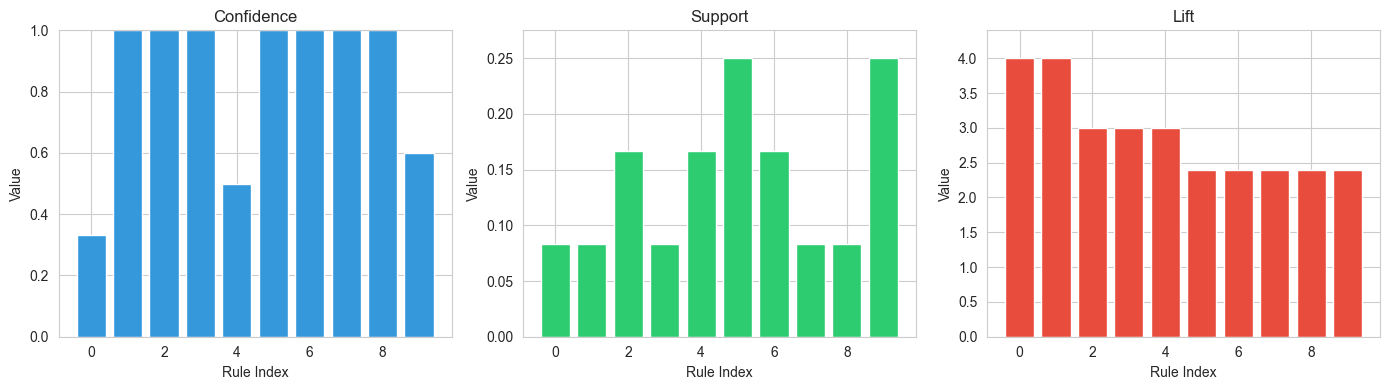


✓ Visualization complete


In [30]:
# Analyze association rules
print("Top Association Rules:")
print("=" * 80)

rules_data = []
if hasattr(arm_model, 'rules') and arm_model.rules is not None and not arm_model.rules.empty:
    # Get all rules (rules is a DataFrame)
    for idx, rule in arm_model.rules.head(10).iterrows():
        antecedent_str = ', '.join(list(rule['antecedents'])[:3])
        consequent_str = ', '.join(list(rule['consequents'])[:3])
        
        rules_data.append({
            'Rule': f"{antecedent_str} → {consequent_str}",
            'Support': f"{rule['support']:.4f}",
            'Confidence': f"{rule['confidence']:.4f}",
            'Lift': f"{rule['lift']:.4f}"
        })

if rules_data:
    rules_df = pd.DataFrame(rules_data)
    print(rules_df.to_string(index=False))
    
    # Visualize rule metrics
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    confidences = [float(r['Confidence']) for r in rules_data]
    supports = [float(r['Support']) for r in rules_data]
    lifts = [float(r['Lift']) for r in rules_data]
    
    axes[0].bar(range(len(confidences)), confidences, color='#3498db')
    axes[0].set_title('Confidence')
    axes[0].set_ylabel('Value')
    axes[0].set_ylim([0, 1])
    axes[0].set_xlabel('Rule Index')
    
    axes[1].bar(range(len(supports)), supports, color='#2ecc71')
    axes[1].set_title('Support')
    axes[1].set_ylabel('Value')
    axes[1].set_ylim([0, max(supports) * 1.1 if supports else 0.1])
    axes[1].set_xlabel('Rule Index')
    
    axes[2].bar(range(len(lifts)), lifts, color='#e74c3c')
    axes[2].set_title('Lift')
    axes[2].set_ylabel('Value')
    axes[2].set_ylim([0, max(lifts) * 1.1 if lifts else 0.1])
    axes[2].set_xlabel('Rule Index')
    
    plt.tight_layout()
    plt.show()
    print("\n✓ Visualization complete")
else:
    print("No association rules found")

## Summary

**Association Rule Mining Results:**
- Apriori algorithm applied to transaction data
- Frequent itemsets discovered
- Association rules generated with support, confidence, and lift metrics
- Rules can be used for cross-selling and product bundle recommendations
- Ready for hybrid model combination